In [24]:
import xarray as xr
import pooch
ds = xr.open_dataset("https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/pressure/hgt.201810.nc", engine="netcdf4")

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'hgt' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [53]:
print(ds)

<xarray.Dataset> Size: 348MB
Dimensions:            (time: 31, level: 29, y: 277, x: 349, nbnds: 2)
Coordinates:
  * time               (time) datetime64[ns] 248B 2018-10-01 ... 2018-10-31
  * level              (level) float32 116B 1e+03 975.0 950.0 ... 125.0 100.0
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 496B ...
    hgt                (time, level, y, x) float32 348MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institu

In [82]:
dsP = xr.open_dataset("https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/monolevel/apcp.2018.nc", engine="netcdf4")
print(dsP)

<xarray.Dataset> Size: 142MB
Dimensions:            (time: 365, y: 277, x: 349, nbnds: 2)
Coordinates:
  * time               (time) datetime64[ns] 3kB 2018-01-01 ... 2018-12-31
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 6kB ...
    apcp               (time, y, x) float32 141MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institution:                     National Centers for Environmental Predi...
    ...                    

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'apcp' has multiple fill values {9.96921e+36, -9.96921e+36} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


In [26]:
import cartopy
import cartopy.crs as ccrs

In [85]:
apcp = dsP.apcp.sel(time='2018-10-15')
hgt = ds.hgt.sel(time='2018-10-15', level =500)
print(apcp)

<xarray.DataArray 'apcp' (y: 277, x: 349)> Size: 387kB
[96673 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2018-10-15
  * y        (y) float32 1kB 0.0 3.246e+04 6.493e+04 ... 8.927e+06 8.96e+06
  * x        (x) float32 1kB 0.0 3.246e+04 6.493e+04 ... 1.126e+07 1.13e+07
    lat      (y, x) float32 387kB ...
    lon      (y, x) float32 387kB ...
Attributes: (12/14)
    GRIB_id:        61
    GRIB_name:      APCP
    grid_mapping:   Lambert_Conformal
    level_desc:     Surface
    standard_name:  precipitation_amount
    units:          kg/m^2
    ...             ...
    long_name:      Daily accumulated total precipitation at Surface
    parent_stat:    Individual Obs
    statistic:      Sum
    valid_range:    [  0. 800.]
    actual_range:   [  0.   332.75]
    _ChunkSizes:    [  1 277 349]


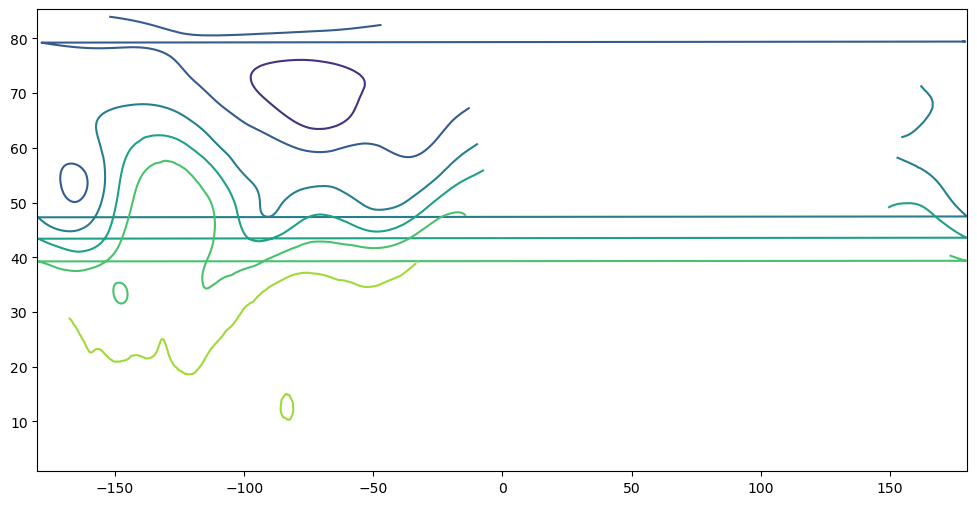

In [86]:
lon = hgt['lon'].values
lat = hgt['lat'].values
data = hgt.values

lonP = apcp['lon'].values
latP = apcp['lat'].values
dataP = apcp.values

plt.contour(lon,lat,data)

In [2]:
extent = [-120, -70, 20, 51]
central_lon = np.mean(extent[0:2])
central_lat = np.mean(extent[2:])
ax = plt.axes(projection=ccrs.Orthographic(
    central_lon,central_lat))
ax.set_extent(extent)
ax.gridlines()
ax.coastlines(resolution='50m')
ax.add_feature(cartopy.feature.STATES, edgecolor='k')
ax.contour(lon, lat, data, cmap="Purples", transform=ccrs.PlateCarree(),
          shrink=0.5)
ax.contourf(lonP,latP, dataP, transform=ccrs.PlateCarree(), cmap="Blues",
           vmin=0, vmax=50)

NameError: name 'np' is not defined